In [0]:
%%capture
!apt-get install -y -qq software-properties-common python-software-properties module-init-tools
!add-apt-repository -y ppa:fenics-packages/fenics
!apt-get update -qq
!apt install -y --no-install-recommends fenics
!rm -rf *
from fenics import *
#import math
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate

# Transport-diffusion problem


\begin{equation}
  \begin{cases}
    - \mu \Delta u + \boldsymbol{b} \cdot\boldsymbol{\nabla} u = f & \mbox{ in } \Omega, \\
    u = g & \mbox{ on } \partial\Omega
  \end{cases}
\end{equation}

\\

With the following data
\begin{equation}
\begin{cases}
    \boldsymbol{b}=\begin{Bmatrix} 1 & 1 \end{Bmatrix}^T \\
    f=0\\
    \mu=1\\
    g \space \text{obtained from the exact solution below}
  \end{cases}
\end{equation}

\\
Considering the problem with the following exact solution:
    \begin{equation*}
      u(x,y) = \frac{e^{-\mu^{-1}x}-1}{e^{-\mu^{-1}}-1}
             + \frac{e^{-\mu^{-1}y}-1}{e^{-\mu^{-1}}-1}.
    \end{equation*}

## Streamline diffusion method

---



We implement the streamline diffusion method, assuming that the stabilization parameter $\tau$ is given by
$$
\tau = \frac{\delta h}{2||\boldsymbol{b}||}. 
$$
The case $\delta=0$ corresponds to the usual FEM without stabilization.

In [0]:
def solve_transportDiffusion_Problem(n, deg, mu, f, b, g, delta):
  mesh = UnitSquareMesh(n, n, 'crossed')
  V = FunctionSpace(mesh, 'CG', deg)

  def boundary(x, on_boundary):
    return on_boundary
  bc = DirichletBC(V, g, boundary)

  u=TrialFunction(V)
  v=TestFunction(V)

  h=CellDiameter(mesh)
  bnorm=sqrt(dot(b, b))
  tau=delta*h/(2*bnorm)

  a = (mu*inner(grad(u), grad(v)) + inner(b, grad(u))*v)*dx
  a_stab =  tau*inner(b, grad(u))*inner(b, grad(v))*dx
  a = a + a_stab
  L = f * v * dx

  u = Function(V)
  solve(a==L, u, bc)
  return mesh, u

In [0]:
deg = 1
n = 10
mu = 1
f = Constant(0.0)
bx = 1
by = 1
b = Constant((bx, by))

u_exact = Expression('(exp(bx * (x[0] - 1) / mu) - exp(-bx / mu)) / (1 - exp(-bx / mu)) + '
                     '(exp(by * (x[1] - 1) / mu) - exp(-by / mu)) / (1 - exp(-by / mu))',
                     mu=mu, bx=bx, by=by, degree=2*deg+1)
g = u_exact

delta = Constant(0.0)

l2=[]
h10=[]

n = [5, 10, 20, 40, 80, 160]
for i in n:
  mesh, uh = solve_transportDiffusion_Problem(i, deg, mu, f, b, g, delta)
  l2.append(errornorm(u_exact, uh, 'L2'))
  h10.append(errornorm(u_exact, uh, 'H10'))

In [4]:
print(tabulate([['L2 Error', l2[0], l2[1], l2[2], l2[3], l2[4], l2[5]],
                ['H10 Error', h10[0], h10[1], h10[2], h10[3], h10[4], h10[5]]],
               headers=['n', n[0], n[1], n[2], n[3], n[4], n[5]]))

n                   5          10           20           40           80          160
---------  ----------  ----------  -----------  -----------  -----------  -----------
L2 Error   0.00452446  0.00113081  0.000282678  7.06678e-05  1.76669e-05  4.41671e-06
H10 Error  0.0507206   0.0254119   0.0127124    0.00635701   0.00317861   0.00158932


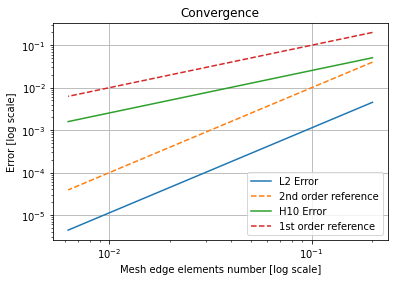

In [5]:
plt.plot(np.divide(1, n), l2)
plt.plot(np.divide(1, n), np.power(np.divide(1, n), 2), '--')
plt.plot(np.divide(1, n), h10)
plt.plot(np.divide(1, n), np.power(np.divide(1, n), 1), '--')
plt.grid()
plt.title('Convergence')
plt.ylabel('Error [log scale]')
plt.xlabel('Mesh edge elements number [log scale]')
plt.yscale('log')
plt.xscale('log')
plt.legend(('L2 Error', '2nd order reference', 'H10 Error', '1st order reference'))
plt.show()

It is possible to observe that with low viscosity convergence speed is lost:
\begin{equation}
  \text{with } \mu=10^{-2}
\end{equation}

In [0]:
mu=1.e-2
n = [5, 10, 20, 40, 80, 160]
l2=[]
h10=[]
for i in n:
  mesh, uh = solve_transportDiffusion_Problem(i, deg, mu, f, b, g, delta)
  l2.append(errornorm(u_exact, uh, 'L2'))
  h10.append(errornorm(u_exact, uh, 'H10'))

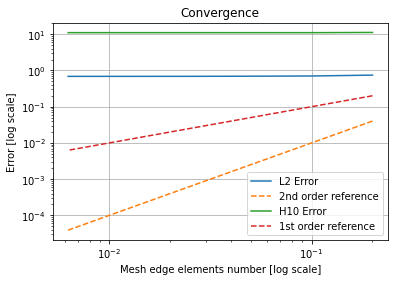

In [7]:
plt.plot(np.divide(1, n), l2)
plt.plot(np.divide(1, n), np.power(np.divide(1, n), 2), '--')
plt.plot(np.divide(1, n), h10)
plt.plot(np.divide(1, n), np.power(np.divide(1, n), 1), '--')
plt.grid()
plt.title('Convergence')
plt.ylabel('Error [log scale]')
plt.xlabel('Mesh edge elements number [log scale]')
plt.yscale('log')
plt.xscale('log')
plt.legend(('L2 Error', '2nd order reference', 'H10 Error', '1st order reference'))
plt.show()

## Strongly Consistent Methods
### SUPG, GLS, and DW stabilization
---

As stabilization parameter $\tau$ we take
$$
\tau = \frac{\delta h}{2||\boldsymbol{b}||} \min\left\{1,\frac{\mathcal{Pe}}3\right\}, \quad\text{with }\;\;  \mathcal{Pe}= \frac{||\boldsymbol{b}||h}{2\mu}. 
$$

Observing that:
$$
\begin{aligned}
\int_\Omega (\boldsymbol{b} \cdot\boldsymbol{\nabla} u) v \, d\boldsymbol{x} &=
\frac12 \int_\Omega (\boldsymbol{b} \cdot\boldsymbol{\nabla} u) v \, d\boldsymbol{x} + 
\frac12 \int_\Omega \boldsymbol{\nabla}\cdot(\boldsymbol{b}\ u) v \, d\boldsymbol{x}
\\
&=
\frac12 \int_\Omega (\boldsymbol{b} \cdot\boldsymbol{\nabla} u) v \, d\boldsymbol{x} - 
\frac12 \int_\Omega u(\boldsymbol{b} \cdot\boldsymbol{\nabla} v) \, d\boldsymbol{x}
\end{aligned}
$$

In [8]:
def solve_transportDiffusion_Problem_strongCont(n, deg, mu, f, b, g, delta, rho):
  mesh = UnitSquareMesh(n, n, 'crossed')
  V = FunctionSpace(mesh, 'CG', deg)

  def boundary(x, on_boundary):
    return on_boundary
  bc = DirichletBC(V, g, boundary)

  u=TrialFunction(V)
  v=TestFunction(V)

  h=CellDiameter(mesh)
  bnorm=sqrt(dot(b, b))
  tau_K = 0.5 * delta * h / conditional(bnorm * h > 6 * mu, bnorm, 6 * mu / h)

  a = (mu * dot(grad(u), grad(v)) + dot(b, grad(u)) * v) * dx
  L = f * v * dx

  A = lambda u: -mu * div(grad(u)) + dot(b, grad(u))
  A_S = lambda u: -mu * div(grad(u)) - 0.5 * div(b) * u
  A_SS = lambda u: dot(b, grad(u)) + 0.5 * div(b) * u
  # A_SS = lambda u: 0.5 * dot(b, grad(u)) + 0.5 * div(b * u)

  a_stab = tau_K * A(u) * (A_SS(v) + rho * A_S(v)) * dx
  a = a + a_stab

  u = Function(V)
  solve(a==L, u, bc)
  return mesh, u

# SUPG (rho = 0), GLS (rho = 1), DW (rho = -1)
rho = Constant(0)

# user dependent stabilization parameter
delta = Constant(1.0)

for n in [10, 20, 40, 80, 160]:
  mesh, u = solve_transportDiffusion_Problem_strongCont(n, deg, mu, f, b, g, delta, rho)
  print('n = {}, error L2 = {:.3e}, error H1 = {}'.format(n, 
         errornorm(u_exact, u, 'L2'), errornorm(u_exact, u, 'H10')))

n = 10, error L2 = 6.042e-01, error H1 = 4.896216864322759
n = 20, error L2 = 6.442e-01, error H1 = 6.42585116465673
n = 40, error L2 = 6.742e-01, error H1 = 8.867686872589706
n = 80, error L2 = 6.832e-01, error H1 = 10.374048365048765
n = 160, error L2 = 6.853e-01, error H1 = 10.878782580208393


## Diffusion-transport-reactions

---



\begin{equation*}
  \begin{cases}
    - \mu \Delta u + \boldsymbol{b} \cdot\boldsymbol{\nabla} u + \sigma u = 1 & \mbox{ in } \Omega, \\[5mm]
    u = 0 & \mbox{ on } \partial\Omega,
  \end{cases}
\end{equation*}
with $\sigma=2$, and $\boldsymbol{b}=(x+1,y+1)$. We take different values for the viscosity ranging from $\mu = 10^{-3}$ to $\mu = 10^{−5}$.

Since $\boldsymbol{\nabla}\cdot \boldsymbol{b} = 2 \ne 0$, in order to write the transport term in the skew-symmetric form, the reaction coefficient must be modified, namely
$$
- \mu \Delta u + \boldsymbol{b} \cdot\boldsymbol{\nabla} u + \sigma u = - \mu \Delta u + 
\frac12\boldsymbol{b}\cdot\boldsymbol{\nabla} u + 
\frac12\boldsymbol{\nabla}\cdot(\boldsymbol{b}\ u) 
+ \left(\sigma -\frac12\boldsymbol{\nabla}\cdot\boldsymbol{b} \right)u.
$$

In [0]:
def solve_transportDiffusionReaction_Problem(n, deg, mu, f, b, g, delta, sigma, rho):
  # 1. mesh generation
  mesh = UnitSquareMesh(n, n, 'crossed')

  # 2. definition of finite element space
  V = FunctionSpace(mesh, 'CG', degree)

  g_boundary = Constant(0.0)

  def boundary(x, on_boundary):
      return on_boundary

  bc = DirichletBC(V, g_boundary, boundary)

  # 3. assembling matrices and vectors/
  u = TrialFunction(V)
  v = TestFunction(V)

  W = VectorFunctionSpace(mesh, "CG", 1)
  b = project(b,W)
  bnorm = sqrt(dot(b, b))
  sigma = Constant(2.0)

  h = CellDiameter(mesh)
  tau_K = 0.5 * delta * h / conditional(bnorm * h > 6 * mu, bnorm, 6 * mu / h)

  a = (mu * dot(grad(u), grad(v)) + dot(b, grad(u)) * v + sigma * u * v) * dx
  L = f * v * dx

  A = lambda u: -mu * div(grad(u)) + dot(b, grad(u))
  A_S = lambda u: -mu * div(grad(u)) - 0.5 * div(b) * u
  A_SS = lambda u: dot(b, grad(u)) + 0.5 * div(b) * u

  a_stabilization = tau_K * A(u) * (A_SS(v) + rho * A_S(v)) * dx
  a = a + a_stabilization

  # 4. solving discrete problem
  u = Function(V)
  solve(a == L, u, bc)
  return mesh, u

In [32]:
deg = 1
b = Expression(('x[0]+1', 'x[1]+1'), degree=deg + 1)
n = 5
sigma = Constant(2.0)
delta = Constant(1.0)
g = Constant(0.0)
f = Constant(1.0)
mu = 1e-3
rho = Constant(1)
Peclet = 3.0 / (sqrt(8)*mu*n)
print(Peclet)

mesh, u = solve_transportDiffusionReaction_Problem(n, deg, mu, f, b, g, delta, sigma, rho)

212.13203435596424
